# **Machine Learning:**
  - Try to Mimic human brain(intelligence) with the help of previous data.

# **Supervised Learning**
  - Input features and output is given at the time of training.

## **Linear Regression:**
  - output is linearly dependent on input features.
  - for every line calculate error and then take line with minimum error.
  - y = mx + b -> m = slope, b = intercept

### **Single Variable**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model

In [ ]:
area = [2600,3000,3200,3600,4000]
price = [550000,565000,610000,680000,725000]

# option1 to create dataframe
df = pd.DataFrame()
df['area'] = area
df['price'] = price

#option 2 to create df
df1 = np.column_stack([area,price])
df1 = pd.DataFrame(df1,columns=['area','price'])

In [ ]:
df.head()

,area,price
0,2600,550000
1,3000,565000
2,3200,610000
3,3600,680000
4,4000,725000


In [ ]:
df1.head()

,area,price
0,2600,550000
1,3000,565000
2,3200,610000
3,3600,680000
4,4000,725000


Text(0, 0.5, 'price')

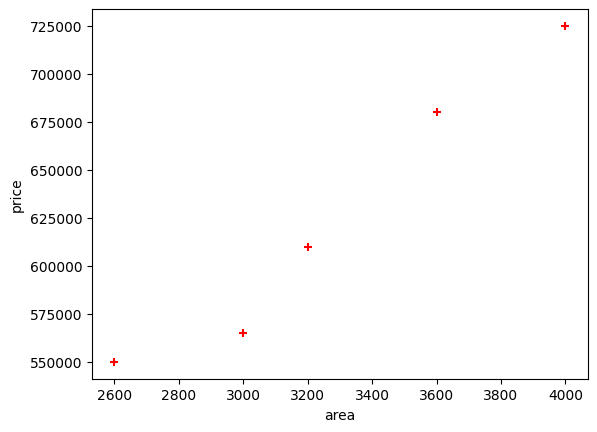

In [ ]:
%matplotlib inline
plt.scatter(df.area,df.price,color='red',marker='+')
plt.xlabel('area')
plt.ylabel('price')

In [ ]:
reg = linear_model.LinearRegression()
reg.fit(df[['area']],df.price)
#This .fit method calculated slope and intercept.

LinearRegression()

In [ ]:
reg.predict([[3300]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([628715.75342466])

In [ ]:
reg.coef_,reg.intercept_

(array([135.78767123]), np.float64(180616.43835616432))

In [ ]:
def predict(x):
  y = 135.78767123*x + 180616.43835616432
  return y

In [ ]:
predict(4120)

740061.6438237643

### **Multiple variables(Multivariate model)**
  - there can be multiple input feature on which final result depends.

In [ ]:
area = [2600,3000,3200,3600,4000]
bedrooms = [3,4,np.nan,3,5]
age = [20,15,18,30,8]
price = [550000,565000,610000,595000,760000]

In [ ]:
df = np.column_stack([area,bedrooms,age,price])
df = pd.DataFrame(df,columns=['area','bedrooms','age','price'])

In [ ]:
# price = m1*area + m2*bedrooms + m3*age + b

#first hanfle empty/null value if any
import math

df.bedrooms = df.bedrooms.fillna(math.floor(df.bedrooms.median()))

In [ ]:
df.head()

,area,bedrooms,age,price
0,2600.0,3.0,20.0,550000.0
1,3000.0,4.0,15.0,565000.0
2,3200.0,3.0,18.0,610000.0
3,3600.0,3.0,30.0,595000.0
4,4000.0,5.0,8.0,760000.0


In [ ]:
reg = linear_model.LinearRegression()
reg.fit(df[['area','bedrooms','age']],df.price)

LinearRegression()

In [ ]:
reg.predict([[3100,4,10]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([636850.])

In [ ]:
reg.coef_

array([   137.25, -26025.  ,  -6825.  ])

In [ ]:
reg.intercept_

np.float64(383724.9999999998)

In [ ]:
def predict(area,bedroom,age):
  y = 137.25*area - 26025*bedroom - 6825*age + 383724.999999
  return y

In [ ]:
predict(3000,3,20)

580899.999999

## **Gradient Descent**
  - updating weights based on calculated cost(MSE,MAE,etc.)
  - it helps find best fit line.
  - derivative of function is slope.
  - after finding slope then multiply it with learning rate.

In [ ]:
import numpy as np
def gradient_descent(x,y):
   m = b = 0
   it = 10000
   learning_rate = 0.08
   n = len(x)

   for i in range(it):
    y_pred = m*x + b
    cost = (1/n)*sum((y - y_pred)**2)
    md = -(2/n)*sum(x*(y - y_pred))
    bd = -(2/n)*sum(y - y_pred)
    m = m - learning_rate*md
    b = b - learning_rate*bd
    print('m {}, b {}, cost {}, iteration {}'.format(m,b,cost,i))



In [ ]:
x = np.array([1,2,3,4,5])
y = np.array([5,7,9,11,13])

gradient_descent(x,y)

m 4.96, b 1.44, cost 89.0, iteration 0
m 0.4991999999999983, b 0.26879999999999993, cost 71.10560000000002, iteration 1
m 4.451584000000002, b 1.426176000000001, cost 56.8297702400001, iteration 2
m 0.892231679999997, b 0.5012275199999995, cost 45.43965675929613, iteration 3
m 4.041314713600002, b 1.432759910400001, cost 36.35088701894832, iteration 4
m 1.2008760606719973, b 0.7036872622079998, cost 29.097483330142282, iteration 5
m 3.7095643080294423, b 1.4546767911321612, cost 23.307872849944438, iteration 6
m 1.4424862661541864, b 0.881337636696883, cost 18.685758762535738, iteration 7
m 3.4406683721083144, b 1.4879302070713722, cost 14.994867596913156, iteration 8
m 1.6308855378034224, b 1.0383405553279617, cost 12.046787238456794, iteration 9
m 3.2221235247119777, b 1.5293810083298451, cost 9.691269350698109, iteration 10
m 1.7770832372205707, b 1.1780607551353204, cost 7.8084968312098315, iteration 11
m 3.0439475772474127, b 1.5765710804477953, cost 6.302918117062937, iteration 1

## **Save Model:**
  - train a specific model and use it later.
  - joblib & pickle: python library's to save model.
  - if we have lot of numpy array then joblib is very efficient.

In [ ]:
import pickle

In [ ]:
with open('model_pickle','wb') as f:
  pickle.dump(reg,f)

In [ ]:
model = pickle.load(open('model_pickle','rb'))

In [ ]:
model.predict([[4200,3,10]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([813850.])

In [ ]:
import joblib

In [ ]:
joblib.dump(reg,'model_joblib')

['model_joblib']

In [ ]:
joblib_model = joblib.load('model_joblib')

In [ ]:
joblib_model.predict([[4200,3,10]])
#

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([813850.])

## **Dummy Variables & One Hot Encoding:**
- catrgorical variables: Nominal and ordinal(with priority)
- one hot encoding: dummy variables

In [ ]:
town = ['monroe township','monroe township','monroe township','monroe township','monroe township','west windsor','west windsor','west windsor','west windsor','robinsville','robinsville','robinsville','robinsville']
area = [2600,3000,3200,3600,4000,2600,2800,3300,3600,2600,2900,3100,3600]
price = [550000,565000,610000,680000,725000,585000,615000,650000,710000,575000,600000,620000,695000]

In [ ]:
import numpy as np
import pandas as pd

df = np.column_stack([town,area,price])
df = pd.DataFrame(df,columns=['town','area','price'])

In [ ]:
df['area'].unique()

array(['2600', '3000', '3200', '3600', '4000', '2800', '3300', '2900',
       '3100'], dtype=object)

In [ ]:
dummies = pd.get_dummies(df.town)

In [ ]:
merged = pd.concat([df,dummies],axis='columns')
merged

,town,area,price,monroe township,robinsville,west windsor
0,monroe township,2600,550000,True,False,False
1,monroe township,3000,565000,True,False,False
2,monroe township,3200,610000,True,False,False
3,monroe township,3600,680000,True,False,False
4,monroe township,4000,725000,True,False,False
5,west windsor,2600,585000,False,False,True
6,west windsor,2800,615000,False,False,True
7,west windsor,3300,650000,False,False,True
8,west windsor,3600,710000,False,False,True
9,robinsville,2600,575000,False,True,False


In [ ]:
final = merged.drop(['town','west windsor'], axis='columns')
final
#dropping one of dummy columns as it is not necessary it all remaining is false that measn that last is true.

,area,price,monroe township,robinsville
0,2600,550000,True,False
1,3000,565000,True,False
2,3200,610000,True,False
3,3600,680000,True,False
4,4000,725000,True,False
5,2600,585000,False,False
6,2800,615000,False,False
7,3300,650000,False,False
8,3600,710000,False,False
9,2600,575000,False,True


In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [ ]:
X = final.drop('price', axis='columns')
X

,area,monroe township,robinsville
0,2600,True,False
1,3000,True,False
2,3200,True,False
3,3600,True,False
4,4000,True,False
5,2600,False,False
6,2800,False,False
7,3300,False,False
8,3600,False,False
9,2600,False,True


In [ ]:
y = final.price
y

,price
0,550000
1,565000
2,610000
3,680000
4,725000
5,585000
6,615000
7,650000
8,710000
9,575000


In [ ]:
model.fit(X,y)

LinearRegression()

In [ ]:
model.predict([[2800,0,1]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([590775.63964739])

In [ ]:
model.predict([[3400,0,0]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([681241.66845839])

In [ ]:
model.score(X,y)


0.9573929037221873

In [ ]:
df

,town,area,price
0,monroe township,2600,550000
1,monroe township,3000,565000
2,monroe township,3200,610000
3,monroe township,3600,680000
4,monroe township,4000,725000
5,west windsor,2600,585000
6,west windsor,2800,615000
7,west windsor,3300,650000
8,west windsor,3600,710000
9,robinsville,2600,575000


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [ ]:
dfle = df
dfle.town = le.fit_transform(dfle.town)

In [ ]:
dfle

,town,area,price
0,0,2600,550000
1,0,3000,565000
2,0,3200,610000
3,0,3600,680000
4,0,4000,725000
5,2,2600,585000
6,2,2800,615000
7,2,3300,650000
8,2,3600,710000
9,1,2600,575000


In [ ]:
X = dfle[['town','area']].values
X

array([[0, '2600'],
       [0, '3000'],
       [0, '3200'],
       [0, '3600'],
       [0, '4000'],
       [2, '2600'],
       [2, '2800'],
       [2, '3300'],
       [2, '3600'],
       [1, '2600'],
       [1, '2900'],
       [1, '3100'],
       [1, '3600']], dtype=object)

In [ ]:
y = dfle.price.values
y

array(['550000', '565000', '610000', '680000', '725000', '585000',
       '615000', '650000', '710000', '575000', '600000', '620000',
       '695000'], dtype=object)

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

ct = ColumnTransformer([('encoder', OneHotEncoder(), [0])], remainder = 'passthrough')


In [ ]:
X = ct.fit_transform(X)
X

(13, 27)

In [ ]:
#after doing OHE remove any one dummy columns and then fir it into model

In [ ]:
car_model = ['BMW X5','BMW X5','BMW X5','BMW X5','BMW X5','Audi A5','Audi A5','Audi A5','Audi A5','Mercedez','Mercedez','Mercedez','Mercedez']
mileage = [69000,35000,57000,22500,46000,59000,52000,72000,91000,67000,83000,79000,59000]
sell_price = [18000,34000,26100,40000,31500,29400,32000,19300,12000,22000,20000,21000,33000]
age = [6,3,5,2,4,5,5,6,8,6,7,7,5]

In [ ]:
df = np.column_stack([car_model,mileage,sell_price,age])
df = pd.DataFrame(df,columns=['car_model','mileage','sell_price','age'])

In [ ]:
df.head()

,car_model,mileage,sell_price,age
0,BMW X5,69000,18000,6
1,BMW X5,35000,34000,3
2,BMW X5,57000,26100,5
3,BMW X5,22500,40000,2
4,BMW X5,46000,31500,4


In [ ]:
#guess price of cars:
# - mercedez, 4yrs old,mileage 45000
# - BMW X5, 7 yr ole, 86000 mileage
# - accuracy

### **train_test_split method from sklearn:**
  - spiltting data into train ans test
  - from sklearn.model_selection import train_test_split
  - some parameters:
    - test_size = 0.2
    - random_state = is it is assigned with some values then that much data will not changes


## **Logistic Regression**
  - if predicted value is contineous then we use linear regression.
  - if predicted value has fixed classes that is called classification problem.
  - logistic regression is one of the techniqu to solve classification problem.
  - binary classification(yes/no - 2 class only)
  - multiclass classification(more than 2 class)
  - logistic regression is applying sigmoid function on top of linear equation.
  - y = 1 / (1 + e^-Z)

In [ ]:
#Binary Classification

age = [22,25,47,52,46,56,55,60,62,61,18,28,27,29,49,55,25,58,19,18,21,26,40,45,50,54,23]
bought_insurance = [0,0,1,0,1,1,0,1,1,1,0,0,0,0,1,1,1,1,0,0,0,0,1,1,1,1,0]

In [ ]:
import numpy as np
import pandas as pd

df = np.column_stack([age,bought_insurance])
df = pd.DataFrame(df,columns=['age','bought_insurance'])

In [ ]:
df.shape

(27, 2)

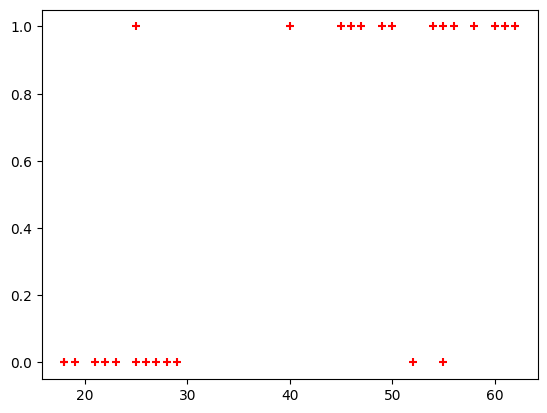

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df.age,df.bought_insurance,marker='+',color='red')

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(df[['age']],df.bought_insurance,test_size=0.1)

In [ ]:
X_test

,age
15,55
2,47
20,21


In [ ]:
X_train

,age
18,19
10,18
4,46
3,52
6,55
26,23
23,45
7,60
19,18
5,56


In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [ ]:
model.fit(X_train,y_train)

LogisticRegression()

In [ ]:
model.predict(X_test)

array([1, 1, 0])

In [ ]:
y_test

,bought_insurance
15,1
2,1
20,0


In [ ]:
model.score(X_test,y_test)


1.0

In [ ]:
model.predict_proba(X_test)

array([[0.12570071, 0.87429929],
       [0.28193356, 0.71806644],
       [0.91134356, 0.08865644]])

In [ ]:
#Multiclass Classification

from sklearn.datasets import load_digits
digits = load_digits()

In [ ]:
digits.data[0]

array([ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
       15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
       12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
        0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
       10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.])

<Figure size 640x480 with 0 Axes>

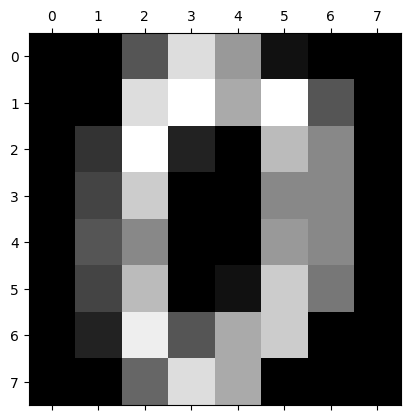

In [ ]:
plt.gray()
plt.matshow(digits.images[0])

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(digits.data,digits.target,test_size=0.2)

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [ ]:
model.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
model.score(X_test,y_test)

0.9694444444444444

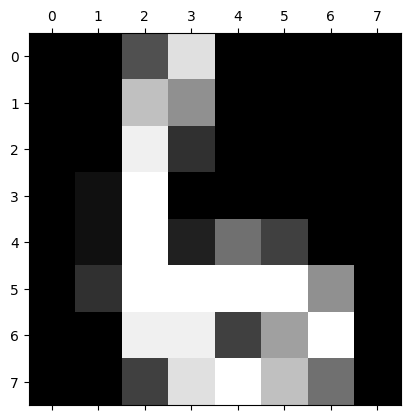

In [ ]:
plt.matshow(digits.images[67])

In [ ]:
digits.target[67]

np.int64(6)

In [ ]:
model.predict([digits.data[67]])

array([6])

In [ ]:
model.predict(digits.data[0:5])

array([0, 1, 2, 3, 4])

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_pred)
cm

array([[38,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0, 42,  0,  0,  1,  0,  0,  0,  0,  0],
       [ 0,  1, 31,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  2, 32,  0,  0,  0,  1,  0,  0],
       [ 0,  0,  0,  0, 38,  0,  0,  0,  0,  1],
       [ 0,  0,  0,  0,  0, 34,  0,  0,  0,  1],
       [ 0,  0,  0,  0,  0,  0, 44,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0, 35,  0,  0],
       [ 0,  2,  0,  0,  0,  1,  0,  0, 33,  1],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0, 22]])

Text(95.72222222222221, 0.5, 'Truth')

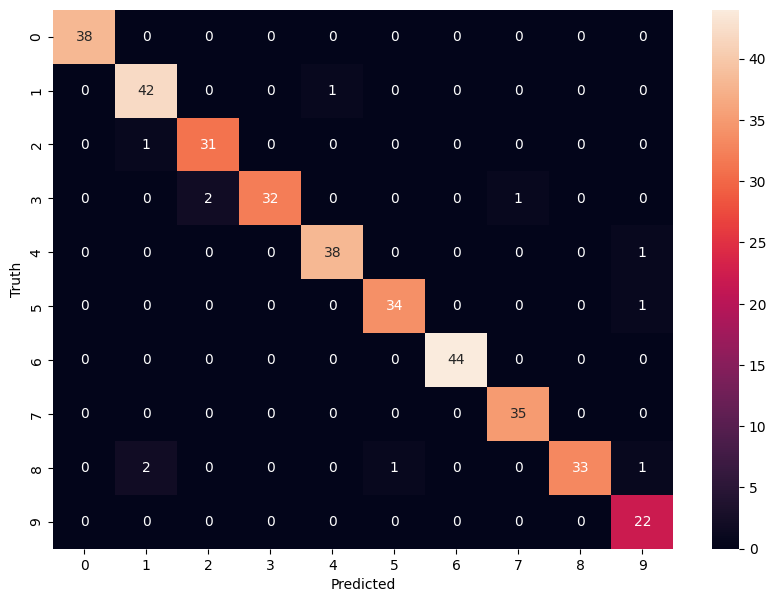

In [ ]:
import seaborn as sn
plt.figure(figsize=(10,7))
sn.heatmap(cm,annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')

## **Decision Tree :**
  - If Dataset is too complex and we are not able to draw a line and if there are multiple condition based classification then we use decision tree.
  - entropy is measurement of randomness.
  - for each feature we calculate entropy and feature with low entropy will be ordered first.
  - low entropy means high information gain.
  - gini impurity: impurity in dataset. data points which are out of their class.

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
company = ["google","google","google","google","google","google","abc pharma","abc pharma","abc pharma","abc pharma","facebook","facebook","facebook","facebook","facebook","facebook"]
job = ["sales executive","sales executive","business manager","business manager","computer programmer","computer programmer","sales executive","computer programmer","business manager","business manager","sales executive","sales executive","business manager","business manager","computer programmer","computer programmer"]
degree = ["bachelors","masters","bachelors","masters","bachelors","masters","masters","bachelors","bachelors","masters","bachelors","masters","bachelors","masters","bachelors","masters"]
salary = [0,0,1,1,0,1,0,0,0,1,1,1,1,1,1,1]

In [ ]:
df = np.column_stack([company,job,degree,salary])
df = pd.DataFrame(df,columns=['company','job','degree','salary'])

In [ ]:
df.head()

,company,job,degree,salary
0,google,sales executive,bachelors,0
1,google,sales executive,masters,0
2,google,business manager,bachelors,1
3,google,business manager,masters,1
4,google,computer programmer,bachelors,0


In [ ]:
inputs = df.drop('salary',axis='columns')
target = df['salary']

In [ ]:
from sklearn.preprocessing import LabelEncoder

le_company = LabelEncoder()
le_job = LabelEncoder()
le_degree = LabelEncoder()

In [ ]:
inputs['company'] = le_company.fit_transform(inputs['company'])
inputs['job'] = le_company.fit_transform(inputs['job'])
inputs['degree'] = le_company.fit_transform(inputs['degree'])

In [ ]:
inputs.head()

,company,job,degree
0,2,2,0
1,2,2,1
2,2,0,0
3,2,0,1
4,2,1,0


In [ ]:
from sklearn import tree

model = tree.DecisionTreeClassifier()

model.fit(inputs,target)

DecisionTreeClassifier()

In [ ]:
model.score(inputs,target)

1.0

In [ ]:
model.predict([[2,2,1]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array(['0'], dtype=object)

### **Excercise**:

In [ ]:
import pandas as pd

In [ ]:
df1 = pd.read_csv('titanic.csv')
df = df1.drop(['PassengerId','Name','SibSp','Parch','Ticket','Cabin','Embarked'],axis='columns')


In [ ]:
df

,Survived,Pclass,Sex,Age,Fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500
...,...,...,...,...,...
886,0,2,male,27.0,13.0000
887,1,1,female,19.0,30.0000
888,0,3,female,NaN,23.4500
889,1,1,male,26.0,30.0000


In [ ]:
#converting categorical values into numeric
from sklearn.preprocessing import LabelEncoder
le_sex = LabelEncoder()

df['Sex'] = le_sex.fit_transform(df['Sex'])

In [ ]:
df['Pclass'].isna().sum()

np.int64(0)

In [ ]:
df['Sex'].isna().sum()

np.int64(0)

In [ ]:
df.Fare.isna().sum()

np.int64(0)

In [ ]:
df['Age'].isna().sum()

np.int64(177)

In [ ]:
df['Age'].fillna(df['Age'].median(),inplace=True)

/tmp/ipykernel_6371/1527141296.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(),inplace=True)


In [ ]:
df.Age.isna().sum()

np.int64(0)

In [ ]:
X = df.drop('Survived',axis='columns')
y = df.Survived

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [ ]:
from sklearn import tree

model = tree.DecisionTreeClassifier()

model.fit(X_train,y_train)

DecisionTreeClassifier()

In [ ]:
model.score(X_test,y_test)

0.7430167597765364

In [ ]:
df

,Survived,Pclass,Sex,Age,Fare
0,0,3,1,22.0,7.2500
1,1,1,0,38.0,71.2833
2,1,3,0,26.0,7.9250
3,1,1,0,35.0,53.1000
4,0,3,1,35.0,8.0500
...,...,...,...,...,...
886,0,2,1,27.0,13.0000
887,1,1,0,19.0,30.0000
888,0,3,0,28.0,23.4500
889,1,1,1,26.0,30.0000


In [ ]:
#trying to normalize Age and Fare.
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[['Age','Fare']] = scaler.fit_transform(df[['Age','Fare']])

In [ ]:
df

,Survived,Pclass,Sex,Age,Fare
0,0,3,1,0.271174,0.014151
1,1,1,0,0.472229,0.139136
2,1,3,0,0.321438,0.015469
3,1,1,0,0.434531,0.103644
4,0,3,1,0.434531,0.015713
...,...,...,...,...,...
886,0,2,1,0.334004,0.025374
887,1,1,0,0.233476,0.058556
888,0,3,0,0.346569,0.045771
889,1,1,1,0.321438,0.058556


In [ ]:
X = df.drop('Survived',axis='columns')
y = df.Survived

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [ ]:
from sklearn import tree

model = tree.DecisionTreeClassifier()

model.fit(X_train,y_train)

DecisionTreeClassifier()

In [ ]:
model.score(X_test,y_test)

0.8044692737430168

## **SVM(Support Vector Machine):**

- In some dataset multiple boundaries are possible to classify dataset but how can we decide whihc boundary is best to find that we use svm.
- take the nearest data point from all class and then calculate distance from line whichever line gives us a lowest distance that is out best fit line.
- that nearest points are support vectors and distance is margin.
  - in 2D it is boundary is line
  - in 2D it is plane
  - in nD it is hyper plane
- SVM finds a hyperplane in multi-dimensional space such that it maximizes margin b/w classification groups.
- Gamma & Regularization:
  - Gamma: high gamma means proper accuracy almost 0 error. low gamma means we allow some errors.
  - same for Regularization(parameter C in sklearn library)


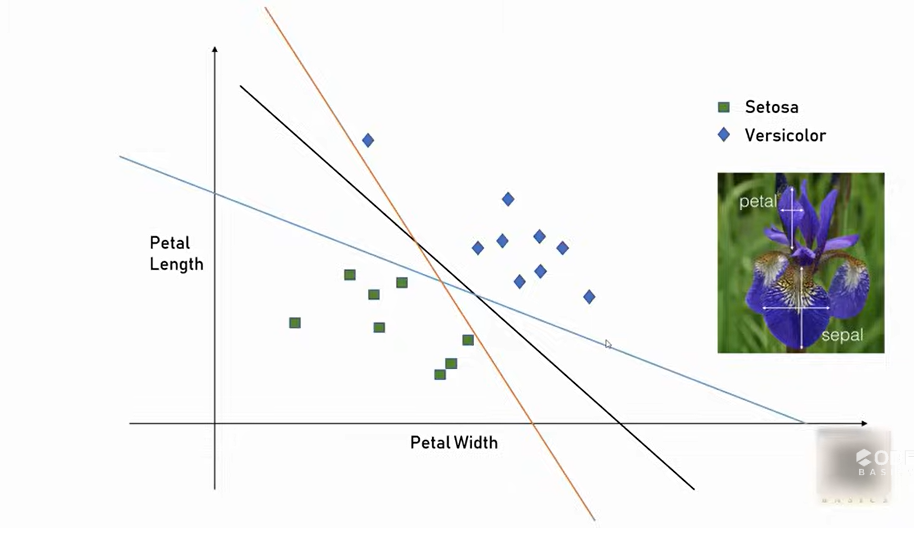

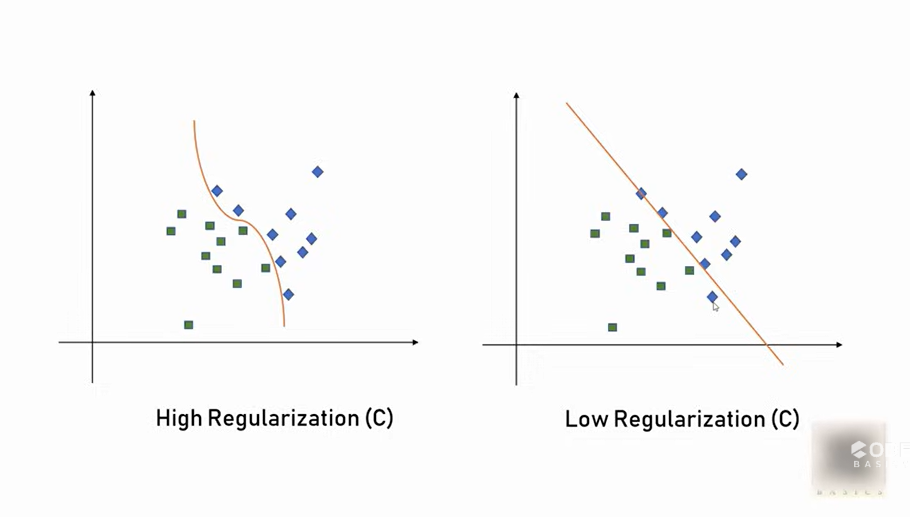

- Kernel:
  - transformation of current data so we can draw boundary easily.

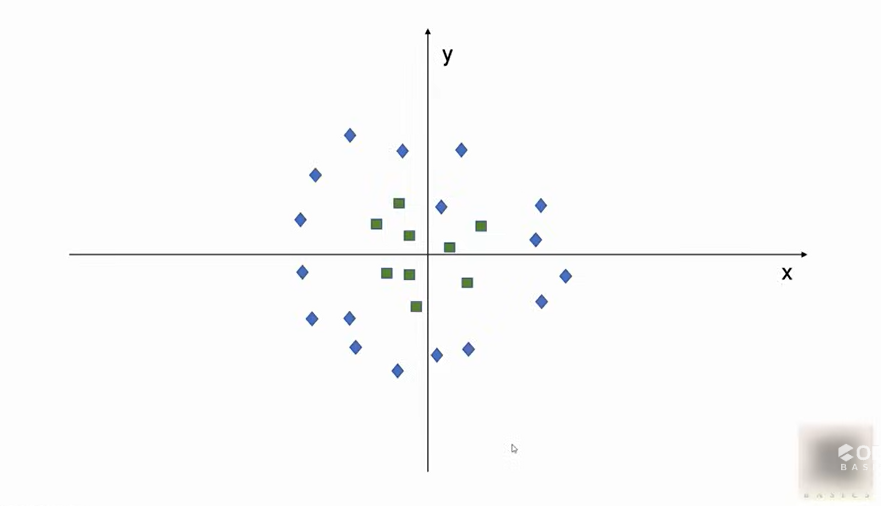

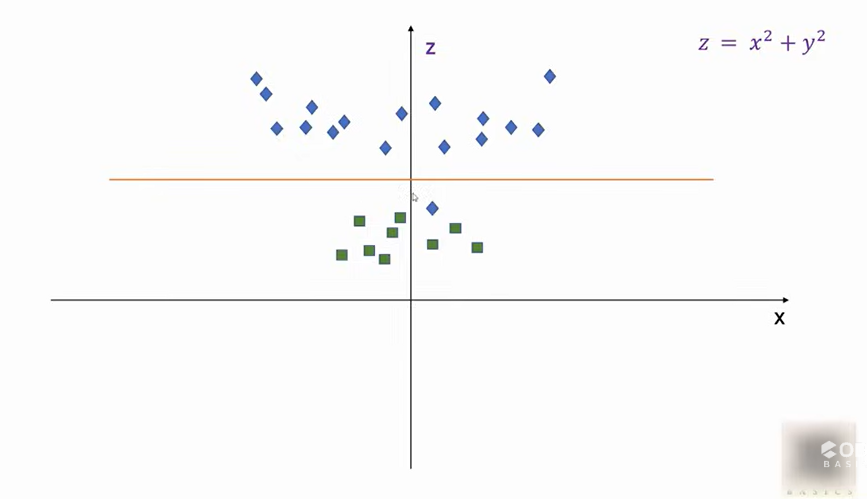

In [ ]:
import pandas as pd
from sklearn.datasets import load_iris
iris = load_iris()

In [ ]:
dir(iris)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [ ]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [ ]:
df = pd.DataFrame(iris.data,columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
df['target'] = iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
df['flower_name'] = df.target.apply(lambda x: iris.target_names[x])
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,flower_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [ ]:
from matplotlib import pyplot as plt
%matplotlib inline

In [ ]:
df0 = df[df.target==0]
df1 = df[df.target==1]
df2 = df[df.target==2]

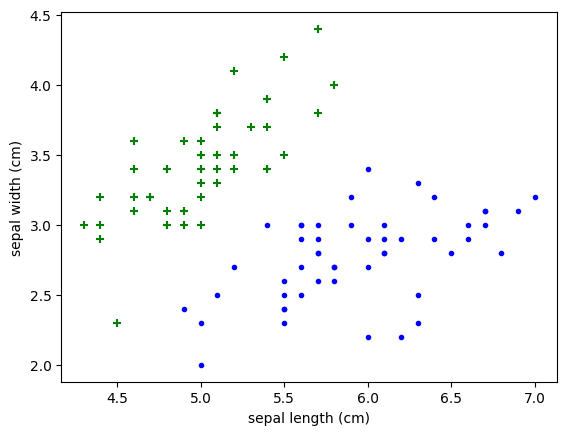

In [ ]:
plt.xlabel('sepal length (cm)')
plt.ylabel('sepal width (cm)')
plt.scatter(df0['sepal length (cm)'],df0['sepal width (cm)'],color='green',marker='+')
plt.scatter(df1['sepal length (cm)'],df1['sepal width (cm)'],color='blue',marker='.')

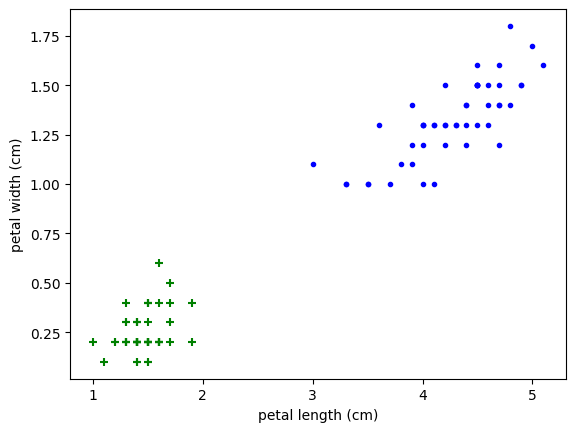

In [ ]:
plt.xlabel('petal length (cm)')
plt.ylabel('petal width (cm)')
plt.scatter(df0['petal length (cm)'],df0['petal width (cm)'],color='green',marker='+')
plt.scatter(df1['petal length (cm)'],df1['petal width (cm)'],color='blue',marker='.')

In [ ]:
X = df.drop(['target','flower_name'],axis='columns')
y = df.target

In [ ]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [ ]:
from sklearn.svm import SVC
model = SVC(C=10,kernel='linear')

In [ ]:
model.fit(x_train,y_train)

SVC(C=10, kernel='linear')

In [ ]:
model.score(x_test,y_test)

1.0

In [ ]:
#Excercise
#from sklearn.datasets import load_digits

## **Random Forest Algorithm**
  - Regression+classification handles both
  - Random Forest is just Extended version of Decision tree.
  - in decision tree we build only 1 tree to predict output.but in Random Forest we divide dataset into batch of n different random sampling and build n decision tree.
  - such we divided samples randomely and builded tree it is called random forest.
  - and for final prediction we do majjority voting.

In [ ]:
import pandas as pd
from sklearn.datasets import load_digits
digits = load_digits()

In [ ]:
dir(digits)

['DESCR', 'data', 'feature_names', 'frame', 'images', 'target', 'target_names']

<Figure size 640x480 with 0 Axes>

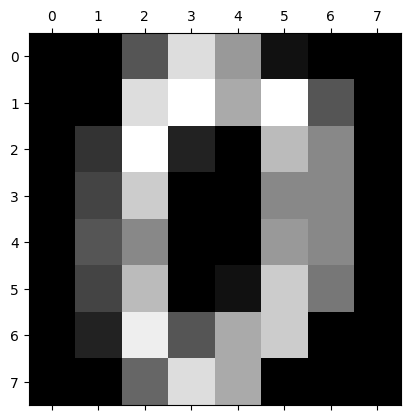

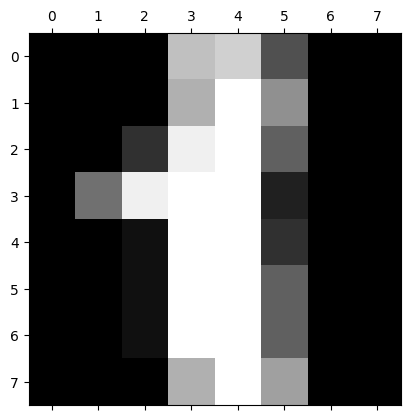

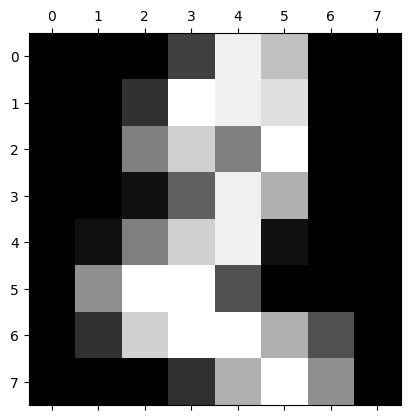

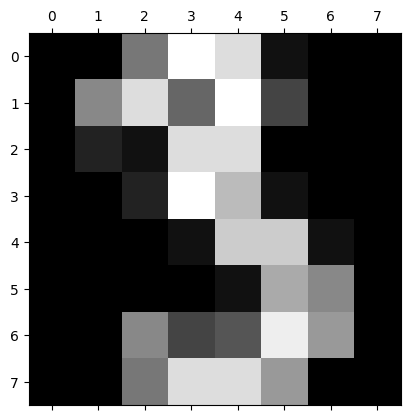

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.gray()
for i in range(4):
  plt.matshow(digits.images[i])

In [ ]:
digits.data[:5]
#each sample of array of size 64 representing 8x8 image

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
        15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
        12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
         0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
        10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.],
       [ 0.,  0.,  0., 12., 13.,  5.,  0.,  0.,  0.,  0.,  0., 11., 16.,
         9.,  0.,  0.,  0.,  0.,  3., 15., 16.,  6.,  0.,  0.,  0.,  7.,
        15., 16., 16.,  2.,  0.,  0.,  0.,  0.,  1., 16., 16.,  3.,  0.,
         0.,  0.,  0.,  1., 16., 16.,  6.,  0.,  0.,  0.,  0.,  1., 16.,
        16.,  6.,  0.,  0.,  0.,  0.,  0., 11., 16., 10.,  0.,  0.],
       [ 0.,  0.,  0.,  4., 15., 12.,  0.,  0.,  0.,  0.,  3., 16., 15.,
        14.,  0.,  0.,  0.,  0.,  8., 13.,  8., 16.,  0.,  0.,  0.,  0.,
         1.,  6., 15., 11.,  0.,  0.,  0.,  1.,  8., 13., 15.,  1.,  0.,
         0.,  0.,  9., 16., 16.,  5.,  0.,  0.,  0.,  0.,  

In [ ]:
df = pd.DataFrame(digits.data)
df['target'] = digits.target
df.head()

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


In [ ]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(df.drop(['target'],axis='columns'),digits.target,test_size=0.2)

In [ ]:
#ensemble is used when multiple algos are running to predict output
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=50)
model.fit(x_train,y_train)

RandomForestClassifier(n_estimators=50)

In [ ]:
model.score(x_test,y_test)

0.9805555555555555

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_pred)
cm

array([[28,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0, 34,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0, 36,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0, 45,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0, 30,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  1,  1, 36,  0,  0,  1,  0],
       [ 0,  0,  0,  0,  0,  0, 36,  0,  0,  0],
       [ 0,  0,  0,  0,  1,  0,  0, 32,  0,  0],
       [ 0,  0,  1,  0,  0,  1,  0,  0, 43,  1],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0, 33]])

Text(95.72222222222221, 0.5, 'Truth')

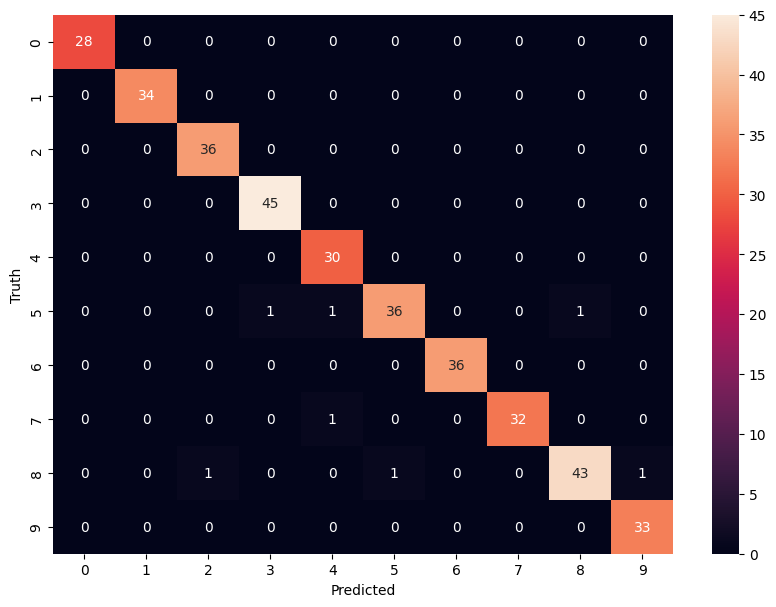

In [ ]:
%matplotlib inline
import seaborn as sn
plt.figure(figsize=(10,7))
sn.heatmap(cm,annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [ ]:
#Excercise: implement RandomForest using iris dataset

## **K Fold Cross Validation**
  - It is Techniche to evaluate model's performance.
  - option 1
    - feed 100% of data at the training time.
  - option 2
    - split dataset in train and test
    - In this type of split model doesn;t have any knowledge about testing dataset.
  - option 3 : k fold cross validation
    - divide entire dataset in k equal part of dataset.
    - from this k datasets use k-1 as training and 1 for testing and do this for all folds iteratively.
    - and then average the score.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import numpy as np
from sklearn.datasets import load_digits

digits = load_digits()

In [ ]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(digits.data,digits.target,test_size=0.3,)

In [ ]:
lr = LogisticRegression()
lr.fit(x_train,y_train)
lr.score(x_test,y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.9574074074074074

In [ ]:
svm = SVC()
svm.fit(x_train,y_train)
svm.score(x_test,y_test)

0.9851851851851852

In [ ]:
rfc = RandomForestClassifier(n_estimators=40)
rfc.fit(x_train,y_train)
rfc.score(x_test,y_test)


0.9555555555555556

In [ ]:
from sklearn.model_selection import KFold
kf = KFold(n_splits=3)
kf

KFold(n_splits=3, random_state=None, shuffle=False)

In [ ]:
for train_index, test_index in kf.split([1,2,3,4,5,6,7,8,9]):
  print(train_index,test_index)

[3 4 5 6 7 8] [0 1 2]
[0 1 2 6 7 8] [3 4 5]
[0 1 2 3 4 5] [6 7 8]


In [ ]:
def get_score(model,x_train,x_test,y_train,y_test):
  model.fit(x_train,y_train)
  return model.score(x_test,y_test)

In [ ]:
#stratify divided all classification categories in unifies way
from sklearn.model_selection import StratifiedKFold
folds = StratifiedKFold(n_splits=3)

In [ ]:
scores_l = []
scores_svm = []
scores_rf = []

for train_index,test_index in folds.split(digits.data,digits.target):
  x_train,x_test,y_train,y_test = digits.data[train_index],digits.data[test_index],\
                                    digits.target[train_index],digits.target[test_index]
  scores_l.append(get_score(LogisticRegression(),x_train,x_test,y_train,y_test))
  scores_svm.append(get_score(SVC(),x_train,x_test,y_train,y_test))
  scores_rf.append(get_score(RandomForestClassifier(n_estimators=40),x_train,x_test,y_train,y_test))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

In [ ]:
scores_l,scores_svm,scores_rf

([0.9215358931552587, 0.9415692821368948, 0.9165275459098498],
 [0.9649415692821369, 0.9799666110183639, 0.9649415692821369],
 [0.9415692821368948, 0.9465776293823038, 0.9215358931552587])

In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
cross_val_score(LogisticRegression(),digits.data,digits.target,cv=3)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

array([0.92153589, 0.94156928, 0.91652755])

In [ ]:
cross_val_score(SVC(),digits.data,digits.target,cv=3)

array([0.96494157, 0.97996661, 0.96494157])

In [ ]:
cross_val_score(RandomForestClassifier(),digits.data,digits.target,cv=3)

array([0.93489149, 0.95492487, 0.92821369])

In [ ]:
#we can do parameter tuning
#Excercise: Perfom same on iris dataset.

# **Unsupervised Learning**
  - no output data while training.
  - only set of features no target variable/class label.

## **K means Clustering**
  - k = number of clusters
  - find centriod of clusters(assume some point initially)
  - find distance of each points from clusters.
  - and after adding point's class average the centroid's value of that cluster by average.
  - keep repeating this process until none of data points change the cluster.
  - How to determine best k??
    - elbow method: start with some random k
    - find sum squared error and find elbow that k is optimistic k.

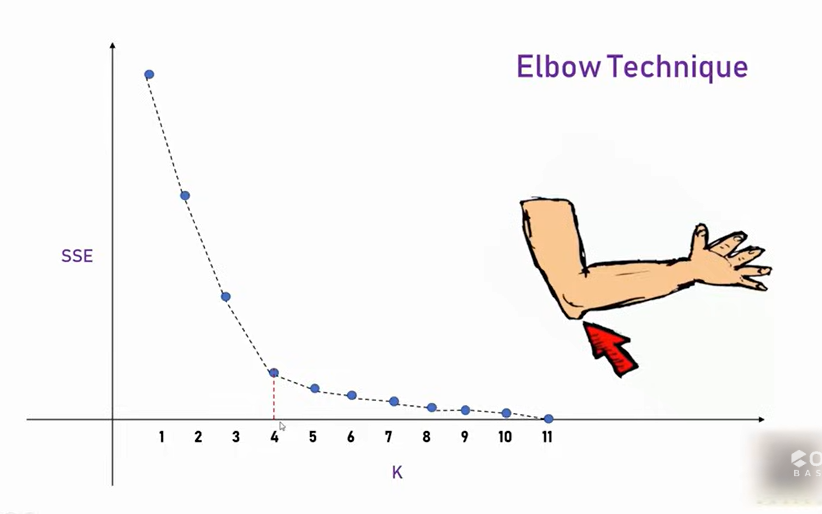

In [ ]:
from sklearn.cluster import KMeans
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from matplotlib import pyplot as plt
%matplotlib inline

In [ ]:
Age = [27,29,29,28,42,39,41,38,36,35,37,26,27,28,29,32,40,41,43,39,42,39]
income = [70000,90000,61000,60000,150000,155000,160000,162000,156000,130000,137000,45000,48000,51000,49500,53000,65000,63000,64000,80000,82000,58000]

In [ ]:
df = pd.DataFrame({'Age':Age,'Income':income})
df.head()

,Age,Income
0,27,70000
1,29,90000
2,29,61000
3,28,60000
4,42,150000


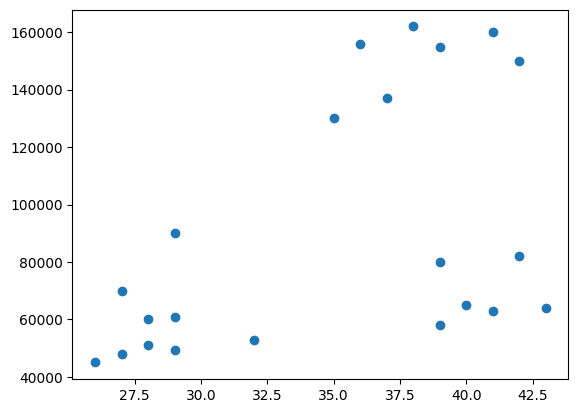

In [ ]:
plt.scatter(df['Age'],df['Income'])

In [ ]:
km = KMeans(n_clusters=3)
km

KMeans(n_clusters=3)

In [ ]:
y_pred = km.fit_predict(df[['Age','Income']])
y_pred

array([1, 0, 1, 1, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1],
      dtype=int32)

In [ ]:
df['cluster'] = y_pred
df.head()

,Age,Income,cluster
0,27,70000,1
1,29,90000,0
2,29,61000,1
3,28,60000,1
4,42,150000,2


/tmp/ipykernel_2091/3131184764.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


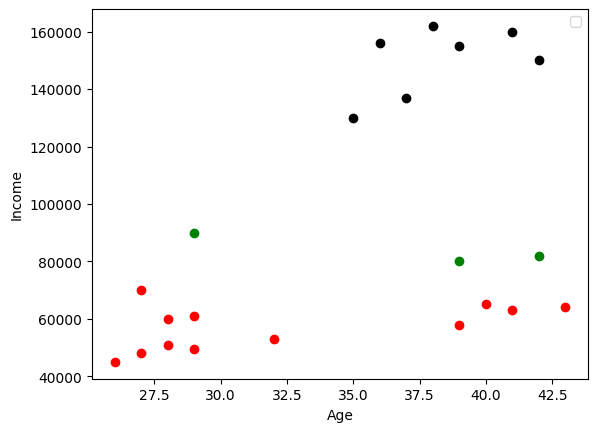

In [ ]:
df1 = df[df.cluster == 0]
df2 = df[df.cluster == 1]
df3 = df[df.cluster == 2]

plt.scatter(df1.Age,df1.Income,color='green')
plt.scatter(df2.Age,df2.Income,color='red')
plt.scatter(df3.Age,df3.Income,color='black')

plt.xlabel('Age')
plt.ylabel('Income')
plt.legend()

In [ ]:
scaler = MinMaxScaler()
df.Age = scaler.fit_transform(df[['Age']])
df.Income = scaler.fit_transform(df[['Income']])

In [ ]:
df.head()

,Age,Income,cluster
0,0.058824,0.213675,1
1,0.176471,0.384615,0
2,0.176471,0.136752,1
3,0.117647,0.128205,1
4,0.941176,0.897436,2


In [ ]:
km = KMeans(n_clusters=3)
y_pred = km.fit_predict(df[['Age','Income']])

In [ ]:
km.cluster_centers_

array([[0.1372549 , 0.11633428],
       [0.72268908, 0.8974359 ],
       [0.8627451 , 0.2022792 ]])

In [ ]:
df['cluster'] = y_pred

/tmp/ipykernel_2091/1455621774.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


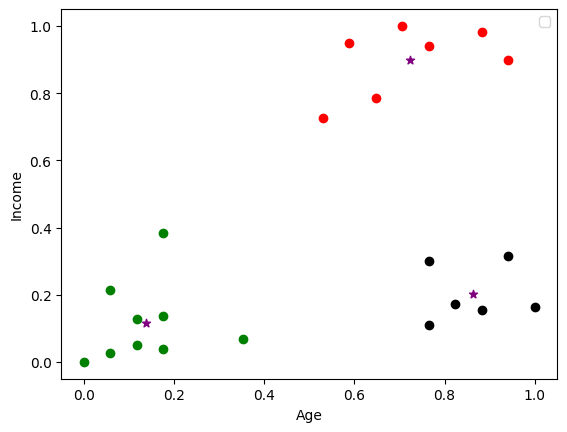

In [ ]:
df1 = df[df.cluster == 0]
df2 = df[df.cluster == 1]
df3 = df[df.cluster == 2]

plt.scatter(df1.Age,df1.Income,color='green')
plt.scatter(df2.Age,df2.Income,color='red')
plt.scatter(df3.Age,df3.Income,color='black')

plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='purple',marker='*')
plt.xlabel('Age')
plt.ylabel('Income')
plt.legend()

In [ ]:
k_range = range(1,10)
sse = []
for k in k_range:
    km = KMeans(n_clusters=k)
    km.fit(df[['Age','Income']])
    sse.append(km.inertia_)

In [ ]:
sse

[5.4800951860995335,
 2.4732811714294334,
 0.4814220638114801,
 0.3554484233981271,
 0.3523234473588873,
 0.22512382288947516,
 0.19191872227871695,
 0.15013800555308254,
 0.14368077236093976]

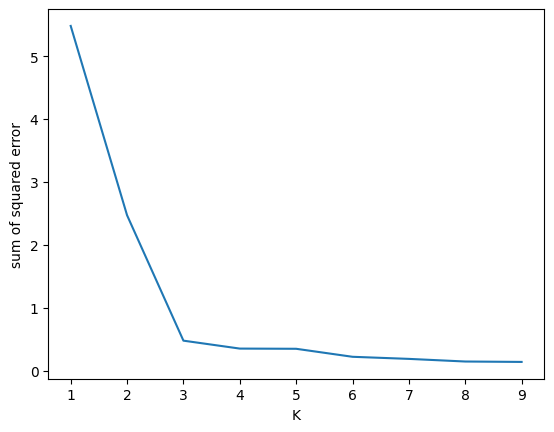

In [ ]:
plt.xlabel('K')
plt.ylabel('sum of squared error')
plt.plot(k_range,sse)
#as in chart at k=3 an elbow is found so that is optimistic classes.

In [ ]:
#Excercise: perform this for kmeans clustering on iris dataset with only 2 features sepal width and petal width

# **Supervised Learning**
  - Input features and output is given at the time of training.

## **Naive BayesClassifier:**
  - Based on Conditional Probability
  - P(A/B) = Probability of event A knowing that event B has already occured
  - P(A/B) = P(B/A) * P(A) / P(B)
  - It is called naive because we make a naive assumption that features are independent of each other.
  - It can be used in email span classifition,digits classification,weather prediction,face Recognization,news classification


In [ ]:
import pandas as pd
df = pd.read_csv('titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.drop(['Name','PassengerId','SibSp','Parch','Ticket','Cabin','Embarked'],axis='columns',inplace=True)
df.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500


In [ ]:
target= df.Survived
inputs = df.drop('Survived',axis='columns')

In [ ]:
dummies = pd.get_dummies(inputs.Sex)
dummies.head()

,female,male
0,False,True
1,True,False
2,True,False
3,True,False
4,False,True


In [ ]:
inputs = pd.concat([inputs,dummies],axis='columns')
inputs.head()

,Pclass,Sex,Age,Fare,female,male
0,3,male,22.0,7.2500,False,True
1,1,female,38.0,71.2833,True,False
2,3,female,26.0,7.9250,True,False
3,1,female,35.0,53.1000,True,False
4,3,male,35.0,8.0500,False,True


In [ ]:
inputs.drop('Sex',axis='columns',inplace=True)
inputs.head()

,Pclass,Age,Fare,female,male
0,3,22.0,7.2500,False,True
1,1,38.0,71.2833,True,False
2,3,26.0,7.9250,True,False
3,1,35.0,53.1000,True,False
4,3,35.0,8.0500,False,True


In [ ]:
inputs.Age = inputs.Age.fillna(inputs.Age.mean())
inputs.head()

,Pclass,Age,Fare,female,male
0,3,22.0,7.2500,False,True
1,1,38.0,71.2833,True,False
2,3,26.0,7.9250,True,False
3,1,35.0,53.1000,True,False
4,3,35.0,8.0500,False,True


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(inputs,target,test_size=0.2)

In [ ]:
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()

In [ ]:
model.fit(X_train,y_train)

GaussianNB()

In [ ]:
model.score(X_test,y_test)

0.776536312849162

In [ ]:
y_test[:10]

,Survived
555,0
409,0
164,0
876,0
158,0
631,0
728,0
399,1
149,0
508,0


In [ ]:
model.predict_proba(X_test[:10])

array([[0.90399149, 0.09600851],
       [0.08544897, 0.91455103],
       [0.97371037, 0.02628963],
       [0.98935045, 0.01064955],
       [0.99089202, 0.00910798],
       [0.99033164, 0.00966836],
       [0.97866155, 0.02133845],
       [0.04267577, 0.95732423],
       [0.98168829, 0.01831171],
       [0.99065667, 0.00934333]])

### **Email Spam Classification**

In [ ]:
import pandas as pd
df = pd.read_csv('spam.csv')
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df.groupby('Category').describe()
#

Message                                                            \
           count unique                                                top   
Category                                                                     
ham         4825   4516                             Sorry, I'll call later   
spam         747    641  Please call our customer service representativ...   

               
         freq  
Category       
ham        30  
spam        4

In [ ]:
df['spam'] = df['Category'].apply(lambda x: 1 if x == 'spam' else 0)
df.head()

,Category,Message,spam
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(df.Message,df.spam,test_size=0.25)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
v = CountVectorizer()
X_train_count = v.fit_transform(X_train.values)
len(X_train_count.toarray()[0])

7468

In [ ]:
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(X_train_count,y_train)

MultinomialNB()

In [ ]:
model.score(X_train_count,y_train)
#

0.9923426657094999

In [ ]:
X_test_count = v.transform(X_test)
model.score(X_test_count,y_test)
#

0.990667623833453

In [ ]:
#Currently ther is only one operation on input data but there may be
#multiple oprations on input data so we can use sklearn's pipeline
from sklearn.pipeline import Pipeline

clf = Pipeline([
    ('vectorizer',CountVectorizer()),
    ('nb',MultinomialNB())
])

In [ ]:
clf.fit(X_train,y_train)

Pipeline(steps=[('vectorizer', CountVectorizer()), ('nb', MultinomialNB())])

In [ ]:
clf.score(X_test,y_test)

0.990667623833453

In [ ]:
#Excercise sklearn's wine dataset and user gaussian and multimonial NB

## **Hyper Parameter Tuning(GridSearchCV)**
  - first problem is to choose model and then which params to choose
  - Process of Choosing best params in called hyper parameter tuning

In [ ]:
from sklearn import svm,datasets
iris = datasets.load_iris()


In [ ]:
import pandas as pd
df = pd.DataFrame(iris.data,columns=iris.feature_names)
df['flower'] = iris.target
df['flower'] = df['flower'].apply(lambda x: iris.target_names[x])
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),flower
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(iris.data,iris.target,test_size=0.3)

In [ ]:
model = svm.SVC(kernel='rbf',C=30,gamma='auto')
model.fit(X_train,y_train)
model.score(X_test,y_test)

0.9777777777777777

In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
cross_val_score(svm.SVC(kernel='linear',C=10,gamma='auto'),iris.data,iris.target,cv=5)

array([1.        , 1.        , 0.9       , 0.96666667, 1.        ])

In [ ]:
cross_val_score(svm.SVC(kernel='rbf',C=10,gamma='auto'),iris.data,iris.target,cv=5)

array([0.96666667, 1.        , 0.96666667, 0.96666667, 1.        ])

In [ ]:
cross_val_score(svm.SVC(kernel='rbf',C=20,gamma='auto'),iris.data,iris.target,cv=5)

array([0.96666667, 1.        , 0.9       , 0.96666667, 1.        ])

In [ ]:
import numpy as np
kerens = ['rbf','linear']
C = [1,10,20]
avg_scores = {}
for kval in kerens:
  for cval in C:
    cv_scores = cross_val_score(svm.SVC(kernel=kval,C=cval,gamma='auto'),iris.data,iris.target,cv=5)
    avg_scores[kval + '_' + str(cval)] = np.average(cv_scores)

avg_scores

{'rbf_1': np.float64(0.9800000000000001),
 'rbf_10': np.float64(0.9800000000000001),
 'rbf_20': np.float64(0.9666666666666668),
 'linear_1': np.float64(0.9800000000000001),
 'linear_10': np.float64(0.9733333333333334),
 'linear_20': np.float64(0.9666666666666666)}

In [ ]:
from sklearn.model_selection import GridSearchCV
#gridsearchcv still uses cross_val
clf = GridSearchCV(svm.SVC(gamma='auto'),{
    'C':[1,10,20],
    'kernel':['rbf','linear'],
},cv=5,return_train_score=False)

In [ ]:
clf.fit(iris.data,iris.target)
clf.cv_results_

{'mean_fit_time': array([0.00132222, 0.00089636, 0.00209651, 0.00113506, 0.00118012,
        0.00109248]),
 'std_fit_time': array([1.51738350e-04, 1.12070590e-04, 1.29455922e-03, 1.83476380e-05,
        7.40759120e-05, 1.76914940e-05]),
 'mean_score_time': array([0.00099454, 0.00075326, 0.00103612, 0.00084896, 0.0008779 ,
        0.00086479]),
 'std_score_time': array([1.14693423e-04, 1.01822387e-04, 2.24549822e-04, 2.74740147e-05,
        8.57564817e-06, 1.06318648e-05]),
 'param_C': masked_array(data=[1, 1, 10, 10, 20, 20],
              mask=[False, False, False, False, False, False],
        fill_value=999999),
 'param_kernel': masked_array(data=['rbf', 'linear', 'rbf', 'linear', 'rbf', 'linear'],
              mask=[False, False, False, False, False, False],
        fill_value=np.str_('?'),
             dtype=object),
 'params': [{'C': 1, 'kernel': 'rbf'},
  {'C': 1, 'kernel': 'linear'},
  {'C': 10, 'kernel': 'rbf'},
  {'C': 10, 'kernel': 'linear'},
  {'C': 20, 'kernel': 'rbf'},
 

In [ ]:
df = pd.DataFrame(clf.cv_results_)
df

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_kernel,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.001322,0.000152,0.000995,0.000115,1,rbf,"{'C': 1, 'kernel': 'rbf'}",0.966667,1.0,0.966667,0.966667,1.0,0.980000,0.016330,1
1,0.000896,0.000112,0.000753,0.000102,1,linear,"{'C': 1, 'kernel': 'linear'}",0.966667,1.0,0.966667,0.966667,1.0,0.980000,0.016330,1
2,0.002097,0.001295,0.001036,0.000225,10,rbf,"{'C': 10, 'kernel': 'rbf'}",0.966667,1.0,0.966667,0.966667,1.0,0.980000,0.016330,1
3,0.001135,0.000018,0.000849,0.000027,10,linear,"{'C': 10, 'kernel': 'linear'}",1.000000,1.0,0.900000,0.966667,1.0,0.973333,0.038873,4
4,0.001180,0.000074,0.000878,0.000009,20,rbf,"{'C': 20, 'kernel': 'rbf'}",0.966667,1.0,0.900000,0.966667,1.0,0.966667,0.036515,5
5,0.001092,0.000018,0.000865,0.000011,20,linear,"{'C': 20, 'kernel': 'linear'}",1.000000,1.0,0.900000,0.933333,1.0,0.966667,0.042164,6


In [ ]:
clf.best_params_

{'C': 1, 'kernel': 'rbf'}

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
#search only random n_iter params in gridsearchcv
rs = RandomizedSearchCV(svm.SVC(gamma='auto'),{
    'C':[1,10,20],
    'kernel':['rbf','linear'],
},cv=5,return_train_score=False,n_iter=2)

In [ ]:
rs.fit(iris.data,iris.target)
pd.DataFrame(rs.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_kernel,param_C,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.006443,0.002696,0.006629,0.000861,rbf,10,"{'kernel': 'rbf', 'C': 10}",0.966667,1.0,0.966667,0.966667,1.0,0.98,0.01633,1
1,0.004285,0.001724,0.003724,0.002034,rbf,1,"{'kernel': 'rbf', 'C': 1}",0.966667,1.0,0.966667,0.966667,1.0,0.98,0.01633,1


In [ ]:
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

In [ ]:
model_params = {
    'svm':{
        'model':svm.SVC(gamma='auto'),
        'params':{
            'C':[1,10,20],
            'kernel':['rbf','linear']
        }
    },
    'random_forest':{
        'model':RandomForestClassifier(),
        'params':{
            'n_estimators':[1,5,10]
        }
    },
    'logistic_regression':{
        'model':LogisticRegression(solver='liblinear',multi_class='auto'),
        'params':{
            'C':[1,5,10]
        }
    }
}


In [ ]:
scores = []

for model_name,mp in model_params.items():
  clf = GridSearchCV(mp['model'],mp['params'],cv=5,return_train_score=False)
  clf.fit(iris.data,iris.target)
  scores.append({
      'model':model_name,
      'best_score':clf.best_score_,
      'best_params':clf.best_params_
  })

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

In [ ]:
df = pd.DataFrame(scores)
df

,model,best_score,best_params
0,svm,0.980000,"{'C': 1, 'kernel': 'rbf'}"
1,random_forest,0.966667,{'n_estimators': 5}
2,logistic_regression,0.966667,{'C': 5}


In [ ]:
#Excercise: sklearn's handwritten digits dataset
#svm,randomforest,logisticregressnion,gaussiaNB,MultinomialNB,DecisioTree do hyper params tuning

## **L1 and L2 Regularization :**
  - Lasso(L1) Regularization:
    - underfit,overfit and balanced fit.
    - under fit - too simple model
    - overfit - too complex model
    
  - L2 Regularization:
    - Adding squares of coefficients of each paramns to Penatly in error calculation.

  - L1 Regularization:
    - Adding Linear of coefficients of each paramns to Penatly in error calculation..

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
dataset = pd.read_csv('Melbourne_housing.csv')
dataset.head()

,Suburb,Address,Rooms,Type,Method,SellerG,Date,Distance,Postcode,Bedroom,...,Landsize,BuildingArea,YearBuilt,CouncilArea,Latitude,Longtitude,Regionname,Propertycount,ParkingArea,Price
0,Abbotsford,68 Studley St,2,h,SS,Jellis,3/9/2016,2.5,3067.0,2.0,...,126.0,inf,NaN,Yarra City Council,-37.8014,144.9958,Northern Metropolitan,4019.0,Carport,NaN
1,Airport West,154 Halsey Rd,3,t,PI,Nelson,3/9/2016,13.5,3042.0,3.0,...,303.0,225,2016.0,Moonee Valley City Council,-37.7180,144.8780,Western Metropolitan,3464.0,Detached Garage,840000.0
2,Albert Park,105 Kerferd Rd,2,h,S,hockingstuart,3/9/2016,3.3,3206.0,2.0,...,120.0,82,1900.0,Port Phillip City Council,-37.8459,144.9555,Southern Metropolitan,3280.0,Attached Garage,1275000.0
3,Albert Park,85 Richardson St,2,h,S,Thomson,3/9/2016,3.3,3206.0,2.0,...,159.0,inf,NaN,Port Phillip City Council,-37.8450,144.9538,Southern Metropolitan,3280.0,Indoor,1455000.0
4,Alphington,30 Austin St,3,h,SN,McGrath,3/9/2016,6.4,3078.0,3.0,...,174.0,122,2003.0,Darebin City Council,-37.7818,145.0198,Northern Metropolitan,2211.0,Parkade,NaN


In [ ]:
dataset.nunique()

,0
Suburb,351
Address,34009
Rooms,12
Type,3
Method,9
SellerG,388
Date,78
Distance,215
Postcode,211
Bedroom,15


In [ ]:
dataset.shape

(34857, 22)

In [ ]:
cols_to_use = ['Suburb','Rooms','Type','Method','SellerG','Regionname','Propertycount',
               'Distance','CouncilArea','Bedroom','Bathroom','Car','Landsize','BuildingArea','Price']

dataset = dataset[cols_to_use]

In [ ]:
dataset.isna().sum()

,0
Suburb,0
Rooms,0
Type,0
Method,0
SellerG,0
Regionname,0
Propertycount,3
Distance,1
CouncilArea,3
Bedroom,8217


In [ ]:
cols_to_fill_zero = ['Propertycount','Distance','Bedroom','Bathroom','Car']

dataset[cols_to_fill_zero] = dataset[cols_to_fill_zero].fillna(0)

dataset.isna().sum()

,0
Suburb,0
Rooms,0
Type,0
Method,0
SellerG,0
Regionname,0
Propertycount,0
Distance,0
CouncilArea,3
Bedroom,0


In [ ]:
dataset['Landsize'] = dataset['Landsize'].fillna(dataset.Landsize.mean())


In [ ]:
dataset.isna().mean()

,0
Suburb,0.000000
Rooms,0.000000
Type,0.000000
Method,0.000000
SellerG,0.000000
Regionname,0.000000
Propertycount,0.000000
Distance,0.000000
CouncilArea,0.000086
Bedroom,0.000000


In [ ]:
dataset.dropna(inplace=True)
dataset.isna().sum()

,0
Suburb,0
Rooms,0
Type,0
Method,0
SellerG,0
Regionname,0
Propertycount,0
Distance,0
CouncilArea,0
Bedroom,0


In [ ]:
dataset = pd.get_dummies(dataset,drop_first=True)
dataset.head()

,Rooms,Propertycount,Distance,Bedroom,Bathroom,Car,Landsize,Price,Suburb_Aberfeldie,Suburb_Airport West,...,BuildingArea_958,BuildingArea_96,BuildingArea_97,BuildingArea_98,BuildingArea_98.5,BuildingArea_99,BuildingArea_99.5,BuildingArea_999,BuildingArea_inf,BuildingArea_missing
1,3,3464.0,13.5,3.0,2.0,1.0,303.0,840000.0,False,True,...,False,False,False,False,False,False,False,False,False,False
2,2,3280.0,3.3,2.0,1.0,0.0,120.0,1275000.0,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2,3280.0,3.3,2.0,1.0,0.0,159.0,1455000.0,False,False,...,False,False,False,False,False,False,False,False,True,False
5,4,2211.0,6.4,3.0,2.0,4.0,853.0,2000000.0,False,False,...,False,False,False,False,False,False,False,False,False,False
6,3,2211.0,6.4,3.0,2.0,2.0,208.0,1110000.0,False,False,...,False,False,False,False,False,False,False,False,True,False


In [ ]:
X = dataset.drop('Price',axis=1)
y = dataset['Price']

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=2)

In [ ]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression().fit(X_train,y_train)

In [ ]:
reg.score(X_test,y_test)

0.6447541634942008

In [ ]:
reg.score(X_train,y_train)

0.8180012217116424

In [ ]:
#The above case is overfitting it performed well in training and poor in testing(new) data
#So we user Regularization L1(Lasso)

from sklearn import linear_model

lasso_reg = linear_model.Lasso(alpha=50, max_iter=100, tol=0.1)

lasso_reg.fit(X_train,y_train)

Lasso(alpha=50, max_iter=100, tol=0.1)

In [ ]:
lasso_reg.score(X_test,y_test)

0.6763183832187083

In [ ]:
lasso_reg.score(X_train,y_train)
#

0.8027991177011884

In [ ]:
# ther is another regularization L2(ridge)

from sklearn.linear_model import Ridge

ridge_reg = Ridge(alpha=50, max_iter=100, tol=0.1)

ridge_reg.fit(X_train,y_train)


Ridge(alpha=50, max_iter=100, tol=0.1)

In [ ]:
ridge_reg.score(X_test,y_test)

0.678691291851292

In [ ]:
ridge_reg.score(X_train,y_train)

0.7015180883632929

## **K nearest neighbors classification(KNN)**
  - find distance of k neighbors and then do assign majority class to current input.
  - find optimum k value by trial and error.(not very high not very low)
  - this distance can be different like euclidian/jacobian etc...

In [ ]:
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()

In [ ]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [ ]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [ ]:
df = pd.DataFrame(iris.data,columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
df.shape

(150, 4)

In [ ]:
df['target'] = iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
df[df.target == 1].head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
50,7.0,3.2,4.7,1.4,1
51,6.4,3.2,4.5,1.5,1
52,6.9,3.1,4.9,1.5,1
53,5.5,2.3,4.0,1.3,1
54,6.5,2.8,4.6,1.5,1


In [ ]:
df[df.target == 2].head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
100,6.3,3.3,6.0,2.5,2
101,5.8,2.7,5.1,1.9,2
102,7.1,3.0,5.9,2.1,2
103,6.3,2.9,5.6,1.8,2
104,6.5,3.0,5.8,2.2,2


In [ ]:
#ploting same as SVM

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X = df.drop(['target'],axis='columns')
y = df.target

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=1)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3)
#metric param in knn is distance type minskowasi = euclidian distance and there is more
knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=3)

In [ ]:
knn.score(X_test,y_test)

1.0

In [ ]:
knn.score(X_train,y_train)

0.95

In [ ]:
from sklearn.metrics import confusion_matrix
y_pred = knn.predict(X_test)

cm = confusion_matrix(y_pred,y_test)

In [ ]:
cm

array([[11,  0,  0],
       [ 0, 13,  0],
       [ 0,  0,  6]])

Text(50.722222222222214, 0.5, 'Truth')

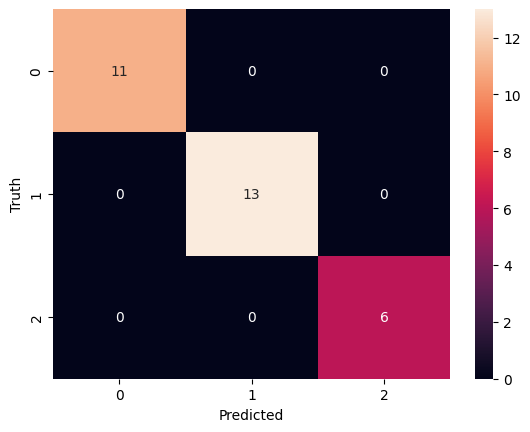

In [ ]:
import seaborn as sn

sn.heatmap(cm,annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00         6

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [ ]:
#Excercise = apply it on digits dataset from sklearn with confusion matrix and classification report and find optimal k value

## **Principal Component Analysis(PCA)**
  - It is a technique to reduce dimensionality
  - some features are very important some are medium important but some are not needed at all.
  - so get rid of non important features meand faster training/inference and data visualization becomes easier.
  - PCA is process to figure most important features.
  - PCA's are a variance/most information so PC1 contained most information , PC2 second most and so on...
  - scale features before applying PCA
  - accuracy might drop(as we are eliminating features and sometime important feature may dropped)
  - dimentionality reduction method.
  - It addresses dimensionality curse

In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_digits

In [ ]:
dataset = load_digits()
dataset.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [ ]:
dataset.data[0]

array([ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
       15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
       12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
        0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
       10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.])

In [ ]:
np.unique(dataset.target)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [ ]:
df = pd.DataFrame(dataset.data,columns=dataset.feature_names)
df.head()

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0


In [ ]:
df.describe()

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
count,1797.0,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,...,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000
mean,0.0,0.303840,5.204786,11.835838,11.848080,5.781859,1.362270,0.129661,0.005565,1.993879,...,3.725097,0.206455,0.000556,0.279354,5.557596,12.089037,11.809126,6.764051,2.067891,0.364496
std,0.0,0.907192,4.754826,4.248842,4.287388,5.666418,3.325775,1.037383,0.094222,3.196160,...,4.919406,0.984401,0.023590,0.934302,5.103019,4.374694,4.933947,5.900623,4.090548,1.860122
min,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.0,0.000000,1.000000,10.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,11.000000,10.000000,0.000000,0.000000,0.000000
50%,0.0,0.000000,4.000000,13.000000,13.000000,4.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,4.000000,13.000000,14.000000,6.000000,0.000000,0.000000
75%,0.0,0.000000,9.000000,15.000000,15.000000,11.000000,0.000000,0.000000,0.000000,3.000000,...,7.000000,0.000000,0.000000,0.000000,10.000000,16.000000,16.000000,12.000000,2.000000,0.000000
max,0.0,8.000000,16.000000,16.000000,16.000000,16.000000,16.000000,15.000000,2.000000,16.000000,...,16.000000,13.000000,1.000000,9.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000


In [ ]:
X = df
y = dataset.target

In [ ]:
#Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()#-1 to 1
X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 0.        , -0.33501649, -0.04308102, ..., -1.14664746,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -1.09493684, ...,  0.54856067,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -1.09493684, ...,  1.56568555,
         1.6951369 , -0.19600752],
       ...,
       [ 0.        , -0.33501649, -0.88456568, ..., -0.12952258,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -0.67419451, ...,  0.8876023 ,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649,  1.00877481, ...,  0.8876023 ,
        -0.26113572, -0.19600752]])

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X_scaled,y,test_size=0.2,random_state=30)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [ ]:
model.score(X_test,y_test)
#

0.9722222222222222

In [ ]:
from sklearn.decomposition import PCA

#in PCA we can supply n(n most important features) or float x(x% information)
pca = PCA(0.95)
X_pca = pca.fit_transform(X)

In [ ]:
X_pca.shape

(1797, 29)

In [ ]:
pca.explained_variance_ratio_

array([0.14890594, 0.13618771, 0.11794594, 0.08409979, 0.05782415,
       0.0491691 , 0.04315987, 0.03661373, 0.03353248, 0.03078806,
       0.02372341, 0.02272697, 0.01821863, 0.01773855, 0.01467101,
       0.01409716, 0.01318589, 0.01248138, 0.01017718, 0.00905617,
       0.00889538, 0.00797123, 0.00767493, 0.00722904, 0.00695889,
       0.00596081, 0.00575615, 0.00515158, 0.0048954 ])

In [ ]:
pca.n_components

0.95

In [ ]:
X_train_pcs,X_test_pcs,y_train,y_test = train_test_split(X_pca,y,test_size=0.2,random_state=30)

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_pcs,y_train)

LogisticRegression(max_iter=1000)

In [ ]:
model.score(X_test_pcs,y_test)

0.9694444444444444

In [ ]:
#instead we can use
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
pca.explained_variance_ratio_
#and then  apply same above logistic Regressino by passing this update pca

array([0.14890594, 0.13618771])

## **Bias vs Variance:**
  - overfit: good accuracy in training but in testing not very good accuracy.
  - overfit means model is too complex so high variance(high variance means test error varies greatly based on selection of training dataset).
  - low bias



  - *variance tells model's complexity means high variability in test error.
  - *bias is measurement of how accurately model can capture a pattern.

  - bias means how near predicted values are with respect to truth
  - variance means how near all data points are.



  - Underfit: poor accuracy in both step train and test.
  - very simple model(not too much complexity) means low variance(test error doesn't vary that much)
  - high bias.

  - Basically bias and variance are in inverse proportion.

  - we need to build a model so that both bias and variance are moderate means train and test error.(balance fit)

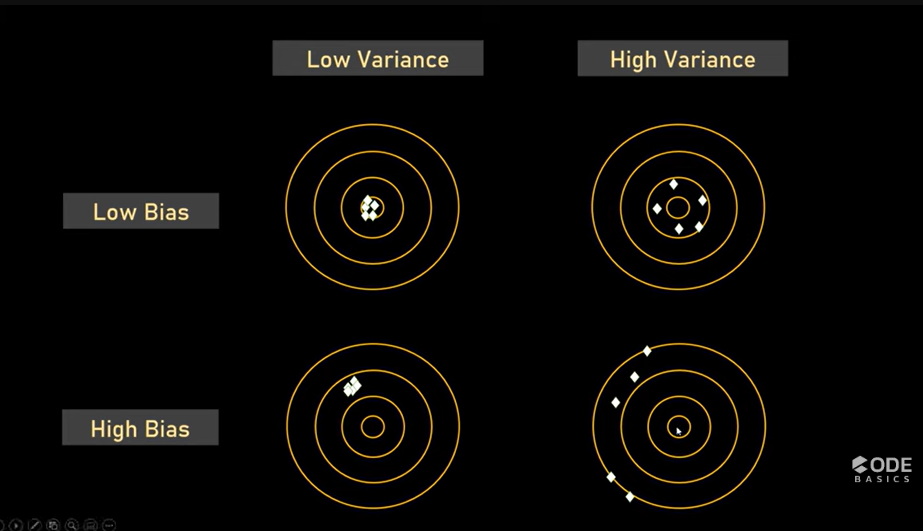

## **Bagging and Boosting:**
  - Ensemble Learning: it means we make final decision based other people/model's opinion(majority voting).
  - bagging and boosting is methods of ensemble learning.

  - resampling with replacement(we might get same dataset multiple time)

  - Bagging: split dataset into multiple batch(bootstrap) and train n different model with that n batch and then do majority vote(aggregation).
  - bagging is also called bootstap aggregation.
  - in classification we do majority while in regression it performs average from all models.

  - Random Forest Algorithm is one of the famous bagging algo where we split based on row as well as column.
  - dataset with n features and m rows we randomely resample itin let say n/2 column(features) and m/2 rows as dataset 1, n/2 + n/3 features and m/2+m/3 rows and so on...this is completely random and then we do aggregation of results and decide final output based on majority voting.

  - Bagging: Underlying model can be anything(svm,knn,logistic regression)
  - Bagged Trees: Each model is tree




In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
df.Outcome.value_counts()

,count
Outcome,
0,500
1,268


In [ ]:
X = df.drop('Outcome',axis='columns')
y = df.Outcome

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:3]

array([[ 0.63994726,  0.84832379,  0.14964075,  0.90726993, -0.69289057,
         0.20401277,  0.46849198,  1.4259954 ],
       [-0.84488505, -1.12339636, -0.16054575,  0.53090156, -0.69289057,
        -0.68442195, -0.36506078, -0.19067191],
       [ 1.23388019,  1.94372388, -0.26394125, -1.28821221, -0.69289057,
        -1.10325546,  0.60439732, -0.10558415]])

In [ ]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(X_scaled,y,stratify=y,random_state=10)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

scores = cross_val_score(DecisionTreeClassifier(), X, y, cv=5)
scores

array([0.68181818, 0.65584416, 0.70779221, 0.77777778, 0.7124183 ])

In [ ]:
scores.mean()

np.float64(0.7071301247771836)

In [ ]:
from sklearn.ensemble import BaggingClassifier

bag_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    max_samples=0.8,
    oob_score=True, # oob - out of bag-it allows all dataset that are not included in training in testing phase.
    random_state=0
  )

bag_model.fit(x_train,y_train)
bag_model.oob_score_
#this .oob_score test model with all datapoint that are not included in any of training means entirely new data.

0.7534722222222222

In [ ]:
scores = cross_val_score(bag_model,X,y,cv=5)

In [ ]:
scores.mean()

np.float64(0.7578728461081402)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

scores = cross_val_score(RandomForestClassifier(),X,y,cv=5)
scores.mean()

np.float64(0.7799932094049742)